In [23]:
!pip install -q ultralytics

In [24]:
from ultralytics import YOLO
from pathlib import Path
import os
import yaml
import matplotlib.pyplot as plt
from PIL import Image

In [25]:
for root, dirs, files in os.walk("/kaggle/input"):
    if "data.yaml" in files:
        print(root)

/kaggle/input/datasets/prabhavsinghal/yolo-data/NEU-DET


In [26]:
DATASET_PATH = "/kaggle/input/datasets/prabhavsinghal/yolo-data/NEU-DET"

yaml_content = f"""
path: {DATASET_PATH}

train: train/images
val: validation/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches
"""

with open("data.yaml","w") as f:
    f.write(yaml_content)

print(open("data.yaml").read())


path: /kaggle/input/datasets/prabhavsinghal/yolo-data/NEU-DET

train: train/images
val: validation/images

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches



In [27]:
with open("data.yaml") as f:
    data = yaml.safe_load(f)

print(data)

base = Path(data["path"])

print(base.exists())

print((base/"train/images").exists())
print((base/"train/labels").exists())

print((base/"validation/images").exists())
print((base/"validation/labels").exists())

{'path': '/kaggle/input/datasets/prabhavsinghal/yolo-data/NEU-DET', 'train': 'train/images', 'val': 'validation/images', 'names': {0: 'crazing', 1: 'inclusion', 2: 'patches', 3: 'pitted_surface', 4: 'rolled-in_scale', 5: 'scratches'}}
True
True
True
True
True


In [28]:
model = YOLO("yolov8n.pt")

In [29]:
model.info()

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [30]:
results = model.train(

    data="data.yaml",

    epochs=50,

    imgsz=640,

    batch=16,

    workers=4,

    optimizer="auto",

    pretrained=True,

    patience=20,

    project="runs",

    name="neu_yolov8n",

    verbose=True

)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=neu_yolov8n-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

In [31]:
metrics = model.val()

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 24.4±9.9 MB/s, size: 13.9 KB)
val: Scanning /kaggle/input/datasets/prabhavsinghal/yolo-data/NEU-DET/validation/labels... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360 737.0it/s 0.5s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/prabhavsinghal/yolo-data/NEU-DET/validation is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 5.8it/s 4.0s0.1s
                   all        360        854      0.701      0.684      0.749      0.399
               crazing         60        162      0.737      0.293      0.542      0.233
             inclusion         71        159      0.693      0.767      0.799      0.456
               patches         73        193      0.

In [32]:
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print(f"mAP50     : {metrics.box.map50:.4f}")
print(f"mAP50-95  : {metrics.box.map:.4f}")

Precision : 0.7005
Recall    : 0.6837
mAP50     : 0.7490
mAP50-95  : 0.3987


(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

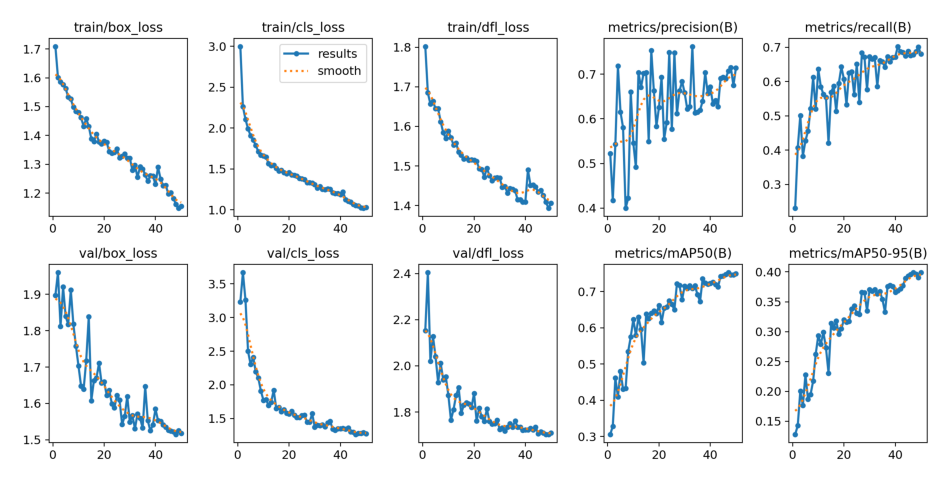

In [34]:
results_png = Image.open("/kaggle/working/runs/detect/runs/neu_yolov8n-2/results.png")

plt.figure(figsize=(12,8))
plt.imshow(results_png)
plt.axis("off")

In [35]:
best_model = YOLO(
    "/kaggle/working/runs/detect/runs/neu_yolov8n-2/weights/best.pt"
)

In [36]:
image_path = f"{DATASET_PATH}/validation/images/crazing_241.jpg"

results = best_model.predict(

    source=image_path,

    conf=0.25,

    save=False,

    verbose=False

)

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

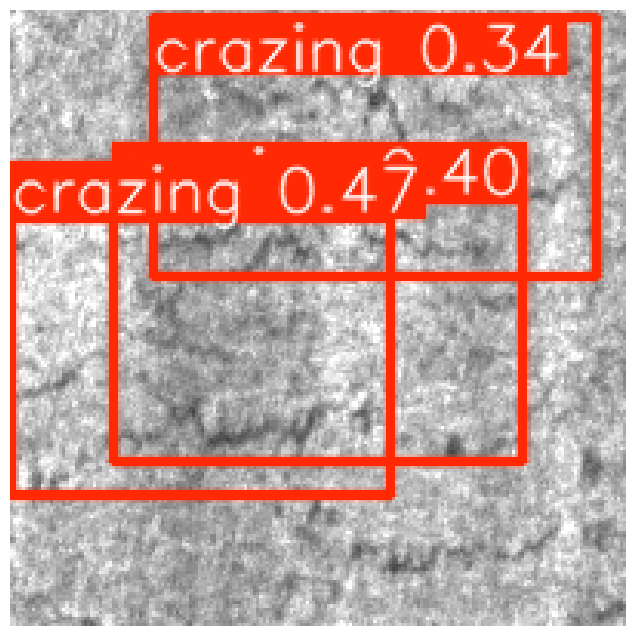

In [37]:
result = results[0]

plt.figure(figsize=(8,8))
plt.imshow(result.plot())
plt.axis("off")